## This notebook is a tutorial to deploy a physics-informed neural network (PINN) to learn the solution to the adjoint of the steady-state relativistic Fokker-Planck equation

100%|███████████████████| 15000/15000 [03:00<00:00, 83.06it/s, L_PDE=1.139e-09, L_BC=1.870e-10, T_PDE=2.161e-09, T_BC=6.781e-10]


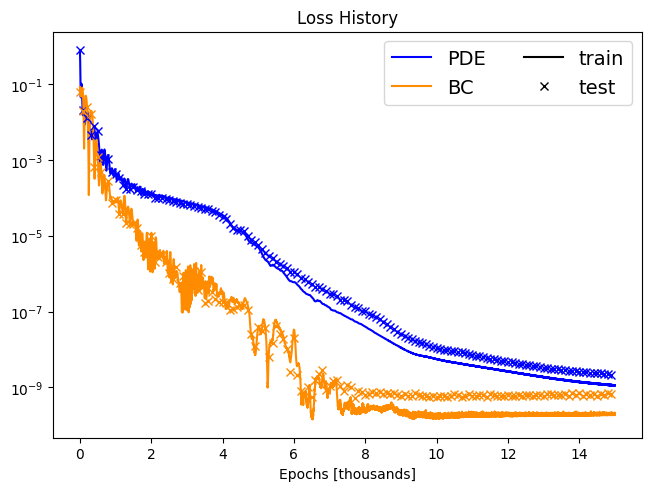

In [7]:
# Corrected, baseline-faithful SCALE-PINN script for RpfPinnTutorial(2).ipynb
# Key guarantees:
# 1) If USE_SCALE_PINN = False, this matches your notebook baseline (same PDE + BC + sampling + training loop).
# 2) If USE_SCALE_PINN = True, only the PDE residual term is modified via SCALE-PINN sequential correction.
#
# SCALE-PINN correction (Allen–Cahn-style form applied to this problem):
#   r̃_k = r_k + (P_k - P_{k-1})/TAU_SC  -  GAMMA_SC*(d2P/dxi2_k - d2P/dxi2_{k-1})/TAU_ALPHA

import copy
import torch
import numpy as np
import tqdm
import pytorch_optimizer
import matplotlib.pyplot as plt

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
torch.manual_seed(1234)
np.random.seed(1234)
torch.set_default_dtype(torch.float64)

# -------------------------
# Toggle
# -------------------------
USE_SCALE_PINN = False   # <-- set False to recover baseline exactly

# -------------------------
# SCALE-PINN hyperparameters (only used if USE_SCALE_PINN=True)
# -------------------------
TAU_SC    = 1.0   # tau_sc
TAU_ALPHA = 1.0   # tau_alpha
GAMMA_SC  = 1.0   # gamma (tunable; in Allen–Cahn gamma = diffusion coefficient)

# -------------------------
# Model (unchanged from notebook)
# -------------------------
class FCNN(torch.nn.Module):
    def __init__(self, in_dim: int, width: int, out_dim: int):
        super().__init__()
        self.act       = torch.nn.Tanh()
        self.input     = torch.nn.Linear(in_dim, width)
        self.layer1    = torch.nn.Linear(width, width)
        self.layer2    = torch.nn.Linear(width, width)
        self.layer3    = torch.nn.Linear(width, width)
        self.output    = torch.nn.Linear(width, out_dim)

        torch.nn.init.xavier_normal_(self.input.weight);  torch.nn.init.zeros_(self.input.bias)
        torch.nn.init.xavier_normal_(self.layer1.weight); torch.nn.init.zeros_(self.layer1.bias)
        torch.nn.init.xavier_normal_(self.layer2.weight); torch.nn.init.zeros_(self.layer2.bias)
        torch.nn.init.xavier_normal_(self.layer3.weight); torch.nn.init.zeros_(self.layer3.bias)
        torch.nn.init.xavier_normal_(self.output.weight); torch.nn.init.zeros_(self.output.bias)

    def forward(self, x):
        x = self.act(self.input(x))
        x = self.act(self.layer1(x))
        x = self.act(self.layer2(x))
        x = self.act(self.layer3(x))
        return self.output(x)

# -------------------------
# Sampling (matches notebook behavior)
# NOTE: Notebook defines generate_edge_points(...) but calls generate_edge_points_2d(...).
# The notebook’s edge selection is left/right only (edge = randint(2,4)).
# We define both names and keep the same behavior.
# -------------------------
def generate_edge_points(num_points, x_min, x_max, y_min, y_max):
    # 0:bottom, 1:top, 2:left, 3:right
    edge = torch.randint(2, 4, (num_points,), device=device)  # left/right only, same as notebook
    r = torch.rand(num_points, device=device)

    x_range = x_max - x_min
    y_range = y_max - y_min

    points = torch.zeros((num_points, 2), device=device, dtype=torch.get_default_dtype())

    points[:, 0] = torch.where(edge < 2, x_min + r * x_range,
                               torch.where(edge == 2, x_min, x_max))
    points[:, 1] = torch.where(edge >= 2, y_min + r * y_range,
                               torch.where(edge == 0, y_min, y_max))
    return points

def generate_edge_points_2d(num_points, x_min, x_max, y_min, y_max):
    return generate_edge_points(num_points, x_min, x_max, y_min, y_max)

# -------------------------
# Plasma parameters + domain bounds (unchanged from notebook)
# -------------------------
Ephi = 1.5
Zeff = 1.0

pMin , pMax  =  0.2, 10.8
xiMin, xiMax = -1.0,  1.0

# -------------------------
# Baseline PDE + BC (EXACTLY matches your notebook)
# -------------------------
def pde(model, X):
    X = X.clone().requires_grad_(True)
    P = model(X)

    dP_dX = torch.autograd.grad(P, X, grad_outputs=torch.ones_like(P), create_graph=True)[0]
    dP_dpbar  = dP_dX[:, 0:1]
    dP_dxibar = dP_dX[:, 1:2]
    d2P_dxibar2 = torch.autograd.grad(
        dP_dxibar, X,
        grad_outputs=torch.ones_like(dP_dxibar),
        create_graph=True
    )[0][:, 1:2]

    dP_dp    = dP_dpbar    /(pMax - pMin)
    dP_dxi   = dP_dxibar   /(xiMax - xiMin)
    d2P_dxi2 = d2P_dxibar2 /(xiMax - xiMin)

    pNorm, xiNorm = X[:, 0:1], X[:, 1:2]
    p  = pNorm  * (pMax  - pMin)  + pMin
    xi = xiNorm * (xiMax - xiMin) + xiMin

    g  = torch.sqrt(1.0 + p**2)
    C_F = g**2/p**2
    C_B = g/p * (Zeff + 1)

    Estar = Ephi*(xi*dP_dp + ((1.0 - xi**2)/p)*dP_dxi)
    Cstar = C_F*dP_dp - C_B/2.0/(p**2)*((1.0 - xi**2)*d2P_dxi2 - 2.0*xi*dP_dxi)

    return Estar + Cstar

def BC(model, X):
    P = model(X)

    pNorm, xiNorm = X[:, 0:1], X[:, 1:2]
    p  = pNorm  * (pMax  - pMin)  + pMin
    xi = xiNorm * (xiMax - xiMin) + xiMin

    g     = torch.sqrt(1.0 + p**2)
    CF    = g**2/p**2
    U_p   = -Ephi * xi - CF

    cond_max = torch.where((U_p > 0) & torch.isclose(pNorm, torch.ones_like(pNorm)), 1.0, 0.0)
    cond_min = torch.isclose(pNorm, torch.zeros_like(pNorm))

    return torch.where(cond_min, P - 0.0, cond_max*(P - 1.0))

# -------------------------
# SCALE-PINN helpers (only used if USE_SCALE_PINN=True)
# -------------------------
def pde_components_for_scale(model, X):
    """
    Returns:
      r_k (baseline residual), P_k, d2P/dxi2_k (physical)
    """
    X = X.clone().requires_grad_(True)
    P = model(X)

    dP_dX = torch.autograd.grad(P, X, grad_outputs=torch.ones_like(P), create_graph=True)[0]
    dP_dxibar = dP_dX[:, 1:2]
    d2P_dxibar2 = torch.autograd.grad(
        dP_dxibar, X,
        grad_outputs=torch.ones_like(dP_dxibar),
        create_graph=True
    )[0][:, 1:2]

    # physical second derivative wrt xi (as in notebook)
    d2P_dxi2 = d2P_dxibar2 / (xiMax - xiMin)

    # baseline residual (call the exact baseline function to guarantee consistency)
    r = pde(model, X)
    return r, P, d2P_dxi2

def pde_scale_pinn(model, model_prev, X, tau_sc, tau_alpha, gamma_sc):
    r_k,    P_k,    d2_k    = pde_components_for_scale(model, X)
    r_prev, P_prev, d2_prev = pde_components_for_scale(model_prev, X)

    S = (P_k - P_prev)/tau_sc - gamma_sc*(d2_k - d2_prev)/tau_alpha
    return r_k + S

# -------------------------
# Data (same counts as notebook)
# -------------------------
Ntrain_pde = 2**11
Ntrain_bc  = 2**8
Xpde = torch.rand(Ntrain_pde, 2, device=device, dtype=torch.get_default_dtype())
Xbc  = generate_edge_points_2d(Ntrain_bc, x_min=0, x_max=1, y_min=0, y_max=1)

Ntest_pde = 2**12
Ntest_bc  = 2**9
Xpde_test = torch.rand(Ntest_pde, 2, device=device, dtype=torch.get_default_dtype())
Xbc_test  = generate_edge_points_2d(Ntest_bc, x_min=0, x_max=1, y_min=0, y_max=1)

# -------------------------
# Initialize model + optimizer (same as notebook)
# -------------------------
model = FCNN(in_dim=2, width=32, out_dim=1).to(device)

optimizer = pytorch_optimizer.optimizer.soap.SOAP(
    model.parameters(), lr=1e-3, betas=(.997, .997),
    weight_decay=0.0, precondition_frequency=1
)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99995)

# Previous-iterate snapshot for SCALE-PINN
model_prev = copy.deepcopy(model).to(device)
model_prev.eval()
for p in model_prev.parameters():
    p.requires_grad_(False)

# -------------------------
# Training loop (baseline-faithful when USE_SCALE_PINN=False)
# -------------------------
Nepochs = 15000
pbar = tqdm.trange(Nepochs, ncols=128)

pde_loss_hist, bc_loss_hist = [], []
pde_test_loss_hist, bc_test_loss_hist = [], []

for i in pbar:
    model.train()
    optimizer.zero_grad()

    if USE_SCALE_PINN:
        r_tilde = pde_scale_pinn(model, model_prev, Xpde, TAU_SC, TAU_ALPHA, GAMMA_SC)
        lp = torch.mean(r_tilde**2)
    else:
        lp = torch.mean(pde(model, Xpde)**2)  # EXACT baseline

    lb = torch.mean(BC(model, Xbc)**2)

    loss = lp + lb
    loss.backward()
    optimizer.step()
    scheduler.step()

    # Update previous iterate AFTER optimizer step (so it's w^{k} stored for next step's w^{k-1})
    if USE_SCALE_PINN:
        model_prev.load_state_dict(model.state_dict())

    pde_loss_hist.append(lp.detach().cpu().numpy())
    bc_loss_hist.append(lb.detach().cpu().numpy())

    model.eval()
    if USE_SCALE_PINN:
        # evaluate scale residual on test points using same prev snapshot (as in training logic)
        r_tilde_t = pde_scale_pinn(model, model_prev, Xpde_test, TAU_SC, TAU_ALPHA, GAMMA_SC)
        lp_t = torch.mean(r_tilde_t**2)
    else:
        lp_t = torch.mean(pde(model, Xpde_test)**2)

    with torch.no_grad():
        lb_t = torch.mean(BC(model, Xbc_test)**2)

    pde_test_loss_hist.append(lp_t.detach().cpu().numpy())
    bc_test_loss_hist.append(lb_t.detach().cpu().numpy())

    pbar.set_postfix({
        "L_PDE": f"{lp.item():.3e}",  "L_BC": f"{lb.item():.3e}",
        "T_PDE": f"{lp_t.item():.3e}","T_BC": f"{lb_t.item():.3e}",
    })

# -------------------------
# Plot loss history (same style as notebook)
# -------------------------
fig, ax = plt.subplots(constrained_layout=True)
ax.set_xlabel("Epochs [thousands]")
ax.set_title("Loss History")
ax.set_yscale("log")

epochs = np.arange(len(pde_loss_hist))/1e3

ax.plot(epochs, pde_loss_hist, label="PDE", c="blue")
ax.plot(epochs, bc_loss_hist,  label="BC",  c="darkorange")
ax.plot(epochs, pde_test_loss_hist, marker="x", c="blue", ls="none", markevery=100)
ax.plot(epochs, bc_test_loss_hist,  marker="x", c="darkorange", ls="none", markevery=100)
ax.plot([], [], ls="-", label="train", c="black")
ax.plot([], [], ls="none", marker="x", label="test", color="black")
ax.legend(fontsize=14, ncol=2)
plt.show()

100%|███████████████████| 15000/15000 [05:26<00:00, 45.95it/s, L_PDE=8.322e-01, L_BC=6.441e-02, T_PDE=1.211e+00, T_BC=5.105e-02]


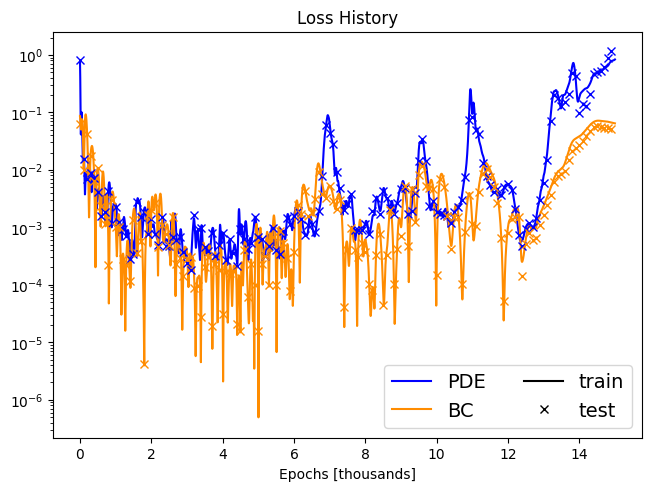

In [8]:
# Corrected, baseline-faithful SCALE-PINN script for RpfPinnTutorial(2).ipynb
# Key guarantees:
# 1) If USE_SCALE_PINN = False, this matches your notebook baseline (same PDE + BC + sampling + training loop).
# 2) If USE_SCALE_PINN = True, only the PDE residual term is modified via SCALE-PINN sequential correction.
#
# SCALE-PINN correction (Allen–Cahn-style form applied to this problem):
#   r̃_k = r_k + (P_k - P_{k-1})/TAU_SC  -  GAMMA_SC*(d2P/dxi2_k - d2P/dxi2_{k-1})/TAU_ALPHA

import copy
import torch
import numpy as np
import tqdm
import pytorch_optimizer
import matplotlib.pyplot as plt

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
torch.manual_seed(1234)
np.random.seed(1234)
torch.set_default_dtype(torch.float64)

# -------------------------
# Toggle
# -------------------------
USE_SCALE_PINN = True   # <-- set False to recover baseline exactly

# -------------------------
# SCALE-PINN hyperparameters (only used if USE_SCALE_PINN=True)
# -------------------------
TAU_SC    = 1.0   # tau_sc
TAU_ALPHA = 1.0   # tau_alpha
GAMMA_SC  = 1.0   # gamma (tunable; in Allen–Cahn gamma = diffusion coefficient)

# -------------------------
# Model (unchanged from notebook)
# -------------------------
class FCNN(torch.nn.Module):
    def __init__(self, in_dim: int, width: int, out_dim: int):
        super().__init__()
        self.act       = torch.nn.Tanh()
        self.input     = torch.nn.Linear(in_dim, width)
        self.layer1    = torch.nn.Linear(width, width)
        self.layer2    = torch.nn.Linear(width, width)
        self.layer3    = torch.nn.Linear(width, width)
        self.output    = torch.nn.Linear(width, out_dim)

        torch.nn.init.xavier_normal_(self.input.weight);  torch.nn.init.zeros_(self.input.bias)
        torch.nn.init.xavier_normal_(self.layer1.weight); torch.nn.init.zeros_(self.layer1.bias)
        torch.nn.init.xavier_normal_(self.layer2.weight); torch.nn.init.zeros_(self.layer2.bias)
        torch.nn.init.xavier_normal_(self.layer3.weight); torch.nn.init.zeros_(self.layer3.bias)
        torch.nn.init.xavier_normal_(self.output.weight); torch.nn.init.zeros_(self.output.bias)

    def forward(self, x):
        x = self.act(self.input(x))
        x = self.act(self.layer1(x))
        x = self.act(self.layer2(x))
        x = self.act(self.layer3(x))
        return self.output(x)

# -------------------------
# Sampling (matches notebook behavior)
# NOTE: Notebook defines generate_edge_points(...) but calls generate_edge_points_2d(...).
# The notebook’s edge selection is left/right only (edge = randint(2,4)).
# We define both names and keep the same behavior.
# -------------------------
def generate_edge_points(num_points, x_min, x_max, y_min, y_max):
    # 0:bottom, 1:top, 2:left, 3:right
    edge = torch.randint(2, 4, (num_points,), device=device)  # left/right only, same as notebook
    r = torch.rand(num_points, device=device)

    x_range = x_max - x_min
    y_range = y_max - y_min

    points = torch.zeros((num_points, 2), device=device, dtype=torch.get_default_dtype())

    points[:, 0] = torch.where(edge < 2, x_min + r * x_range,
                               torch.where(edge == 2, x_min, x_max))
    points[:, 1] = torch.where(edge >= 2, y_min + r * y_range,
                               torch.where(edge == 0, y_min, y_max))
    return points

def generate_edge_points_2d(num_points, x_min, x_max, y_min, y_max):
    return generate_edge_points(num_points, x_min, x_max, y_min, y_max)

# -------------------------
# Plasma parameters + domain bounds (unchanged from notebook)
# -------------------------
Ephi = 1.5
Zeff = 1.0

pMin , pMax  =  0.2, 10.8
xiMin, xiMax = -1.0,  1.0

# -------------------------
# Baseline PDE + BC (EXACTLY matches your notebook)
# -------------------------
def pde(model, X):
    X = X.clone().requires_grad_(True)
    P = model(X)

    dP_dX = torch.autograd.grad(P, X, grad_outputs=torch.ones_like(P), create_graph=True)[0]
    dP_dpbar  = dP_dX[:, 0:1]
    dP_dxibar = dP_dX[:, 1:2]
    d2P_dxibar2 = torch.autograd.grad(
        dP_dxibar, X,
        grad_outputs=torch.ones_like(dP_dxibar),
        create_graph=True
    )[0][:, 1:2]

    dP_dp    = dP_dpbar    /(pMax - pMin)
    dP_dxi   = dP_dxibar   /(xiMax - xiMin)
    d2P_dxi2 = d2P_dxibar2 /(xiMax - xiMin)

    pNorm, xiNorm = X[:, 0:1], X[:, 1:2]
    p  = pNorm  * (pMax  - pMin)  + pMin
    xi = xiNorm * (xiMax - xiMin) + xiMin

    g  = torch.sqrt(1.0 + p**2)
    C_F = g**2/p**2
    C_B = g/p * (Zeff + 1)

    Estar = Ephi*(xi*dP_dp + ((1.0 - xi**2)/p)*dP_dxi)
    Cstar = C_F*dP_dp - C_B/2.0/(p**2)*((1.0 - xi**2)*d2P_dxi2 - 2.0*xi*dP_dxi)

    return Estar + Cstar

def BC(model, X):
    P = model(X)

    pNorm, xiNorm = X[:, 0:1], X[:, 1:2]
    p  = pNorm  * (pMax  - pMin)  + pMin
    xi = xiNorm * (xiMax - xiMin) + xiMin

    g     = torch.sqrt(1.0 + p**2)
    CF    = g**2/p**2
    U_p   = -Ephi * xi - CF

    cond_max = torch.where((U_p > 0) & torch.isclose(pNorm, torch.ones_like(pNorm)), 1.0, 0.0)
    cond_min = torch.isclose(pNorm, torch.zeros_like(pNorm))

    return torch.where(cond_min, P - 0.0, cond_max*(P - 1.0))

# -------------------------
# SCALE-PINN helpers (only used if USE_SCALE_PINN=True)
# -------------------------
def pde_components_for_scale(model, X):
    """
    Returns:
      r_k (baseline residual), P_k, d2P/dxi2_k (physical)
    """
    X = X.clone().requires_grad_(True)
    P = model(X)

    dP_dX = torch.autograd.grad(P, X, grad_outputs=torch.ones_like(P), create_graph=True)[0]
    dP_dxibar = dP_dX[:, 1:2]
    d2P_dxibar2 = torch.autograd.grad(
        dP_dxibar, X,
        grad_outputs=torch.ones_like(dP_dxibar),
        create_graph=True
    )[0][:, 1:2]

    # physical second derivative wrt xi (as in notebook)
    d2P_dxi2 = d2P_dxibar2 / (xiMax - xiMin)

    # baseline residual (call the exact baseline function to guarantee consistency)
    r = pde(model, X)
    return r, P, d2P_dxi2

def pde_scale_pinn(model, model_prev, X, tau_sc, tau_alpha, gamma_sc):
    r_k,    P_k,    d2_k    = pde_components_for_scale(model, X)
    r_prev, P_prev, d2_prev = pde_components_for_scale(model_prev, X)

    S = (P_k - P_prev)/tau_sc - gamma_sc*(d2_k - d2_prev)/tau_alpha
    return r_k + S

# -------------------------
# Data (same counts as notebook)
# -------------------------
Ntrain_pde = 2**11
Ntrain_bc  = 2**8
Xpde = torch.rand(Ntrain_pde, 2, device=device, dtype=torch.get_default_dtype())
Xbc  = generate_edge_points_2d(Ntrain_bc, x_min=0, x_max=1, y_min=0, y_max=1)

Ntest_pde = 2**12
Ntest_bc  = 2**9
Xpde_test = torch.rand(Ntest_pde, 2, device=device, dtype=torch.get_default_dtype())
Xbc_test  = generate_edge_points_2d(Ntest_bc, x_min=0, x_max=1, y_min=0, y_max=1)

# -------------------------
# Initialize model + optimizer (same as notebook)
# -------------------------
model = FCNN(in_dim=2, width=32, out_dim=1).to(device)

optimizer = pytorch_optimizer.optimizer.soap.SOAP(
    model.parameters(), lr=1e-3, betas=(.997, .997),
    weight_decay=0.0, precondition_frequency=1
)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99995)

# Previous-iterate snapshot for SCALE-PINN
model_prev = copy.deepcopy(model).to(device)
model_prev.eval()
for p in model_prev.parameters():
    p.requires_grad_(False)

# -------------------------
# Training loop (baseline-faithful when USE_SCALE_PINN=False)
# -------------------------
Nepochs = 15000
pbar = tqdm.trange(Nepochs, ncols=128)

pde_loss_hist, bc_loss_hist = [], []
pde_test_loss_hist, bc_test_loss_hist = [], []

for i in pbar:
    model.train()
    optimizer.zero_grad()

    if USE_SCALE_PINN:
        r_tilde = pde_scale_pinn(model, model_prev, Xpde, TAU_SC, TAU_ALPHA, GAMMA_SC)
        lp = torch.mean(r_tilde**2)
    else:
        lp = torch.mean(pde(model, Xpde)**2)  # EXACT baseline

    lb = torch.mean(BC(model, Xbc)**2)

    loss = lp + lb
    loss.backward()
    optimizer.step()
    scheduler.step()

    # Update previous iterate AFTER optimizer step (so it's w^{k} stored for next step's w^{k-1})
    if USE_SCALE_PINN:
        model_prev.load_state_dict(model.state_dict())

    pde_loss_hist.append(lp.detach().cpu().numpy())
    bc_loss_hist.append(lb.detach().cpu().numpy())

    model.eval()
    if USE_SCALE_PINN:
        # evaluate scale residual on test points using same prev snapshot (as in training logic)
        r_tilde_t = pde_scale_pinn(model, model_prev, Xpde_test, TAU_SC, TAU_ALPHA, GAMMA_SC)
        lp_t = torch.mean(r_tilde_t**2)
    else:
        lp_t = torch.mean(pde(model, Xpde_test)**2)

    with torch.no_grad():
        lb_t = torch.mean(BC(model, Xbc_test)**2)

    pde_test_loss_hist.append(lp_t.detach().cpu().numpy())
    bc_test_loss_hist.append(lb_t.detach().cpu().numpy())

    pbar.set_postfix({
        "L_PDE": f"{lp.item():.3e}",  "L_BC": f"{lb.item():.3e}",
        "T_PDE": f"{lp_t.item():.3e}","T_BC": f"{lb_t.item():.3e}",
    })

# -------------------------
# Plot loss history (same style as notebook)
# -------------------------
fig, ax = plt.subplots(constrained_layout=True)
ax.set_xlabel("Epochs [thousands]")
ax.set_title("Loss History")
ax.set_yscale("log")

epochs = np.arange(len(pde_loss_hist))/1e3

ax.plot(epochs, pde_loss_hist, label="PDE", c="blue")
ax.plot(epochs, bc_loss_hist,  label="BC",  c="darkorange")
ax.plot(epochs, pde_test_loss_hist, marker="x", c="blue", ls="none", markevery=100)
ax.plot(epochs, bc_test_loss_hist,  marker="x", c="darkorange", ls="none", markevery=100)
ax.plot([], [], ls="-", label="train", c="black")
ax.plot([], [], ls="none", marker="x", label="test", color="black")
ax.legend(fontsize=14, ncol=2)
plt.show()

#### Importing relevant libraries

In [1]:
import torch                       # ML library
import numpy as np                 # numpy for arrays
import tqdm                        # progress bar
import pytorch_optimizer           # optimizer library
import matplotlib.pyplot as plt    # plotting library

#### Choose hardware, RNG seed, and precision

In [23]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')  # Computer hardware
torch.manual_seed(1234)                                                              # PyTorch RNG seed
np.random.seed(1234)                                                                 # Numpy RNG seed
torch.set_default_dtype(torch.float64)                                               # Setting precision

#### Build a fully connected neural network

In [3]:
class FCNN(torch.nn.Module):
    def __init__(self, in_dim: int, width: int, out_dim: int):
        super().__init__()
        self.act       = torch.nn.Tanh()
        self.input     = torch.nn.Linear(in_dim, width)
        self.layer1    = torch.nn.Linear(width, width)
        self.layer2    = torch.nn.Linear(width, width)
        self.layer3    = torch.nn.Linear(width, width) 
        self.output    = torch.nn.Linear(width, out_dim)
        self._init_weights()

    def _init_weights(self):
        for m in [self.input,self.layer1,self.layer2,
                self.layer3,self.output]:
            torch.nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                torch.nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.act(self.input(x))
        x = self.act(self.layer1(x))
        x = self.act(self.layer2(x))
        x = self.act(self.layer3(x))
        x = self.output(x)
        return x

#### Construct the loss terms for the PDE and boundary condition(s)

In [172]:
'''
    PDE loss term
'''
def pde(model, X):
    # Build computational graph for backpropogation
    X = X.clone().requires_grad_(True)

    # Predict dependent variable
    P = model(X)

    # Compute derivatives w.r.t. normalized independent variables
    dP_dX = torch.autograd.grad(P, X, grad_outputs=torch.ones_like(P),create_graph=True)[0]
    dP_dpbar  = dP_dX[:, 0:1]
    dP_dxibar = dP_dX[:, 1:2]
    d2P_dxibar2 = torch.autograd.grad(dP_dxibar, X, grad_outputs=torch.ones_like(dP_dxibar),create_graph=True)[0][:, 1:2]

    # Convert to physical derivatives
    dP_dp    = dP_dpbar    /(pMax - pMin)
    dP_dxi   = dP_dxibar   /(xiMax - xiMin)
    d2P_dxi2 = d2P_dxibar2 /(xiMax - xiMin)
    
    # Physical independent variables
    pNorm, xiNorm = X[:, 0:1], X[:, 1:2]
    p  = pNorm  * (pMax  - pMin)  + pMin
    xi = xiNorm * (xiMax - xiMin) + xiMin

    # Compute derived variables
    g  = torch.sqrt(1.0 + p**2)
    C_F = g**2/p**2
    C_B = g/p * (Zeff + 1)

    # Compute PDE
    Estar = Ephi*(xi*dP_dp + ((1.0 - xi**2)/p)*dP_dxi)
    Cstar = C_F*dP_dp - C_B/2.0/(p**2)*((1.0 - xi**2)*d2P_dxi2 - 2.0*xi*dP_dxi)

    residual = Estar + Cstar
    return residual

'''
    Boundary loss term
'''
def BC(model, X):
    # Predict dependent variable
    P = model(X)
    
    # Physical independent variables
    pNorm, xiNorm = X[:, 0:1], X[:, 1:2]
    p  = pNorm  * (pMax  - pMin)  + pMin
    xi = xiNorm * (xiMax - xiMin) + xiMin
    
    # Compute derived variables
    g     = torch.sqrt(1.0 + p**2)
    CF    = g**2/p**2
    U_p   = -Ephi * xi - CF

    # Build conditionals with the appropriate boundary conditions
    cond_max = torch.where((U_p > 0) & torch.isclose(pNorm,torch.ones_like(pNorm)), 1.0, 0.0)
    cond_min = torch.isclose(pNorm,torch.zeros_like(pNorm))

    # P = 0 if p=p_min, P = 1 if p=p_max
    return torch.where(cond_min, P - 0.0, cond_max*(P - 1.0))


#### Define plasma parameters, domain, and collocation points

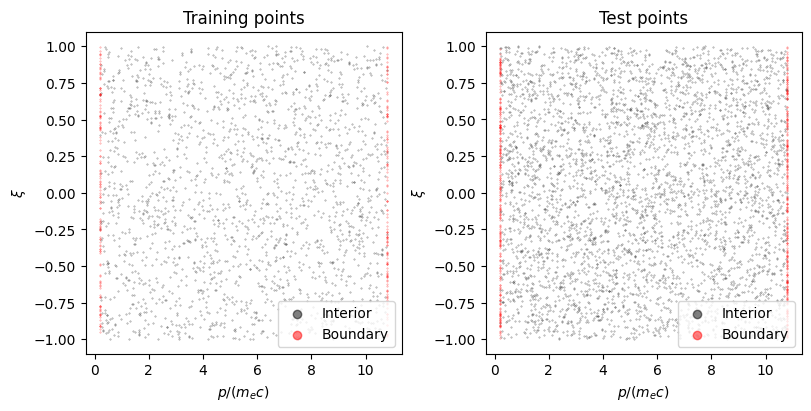

In [191]:
'''
    Function to sample points at p_min and p_max
'''
def generate_edge_points(num_points, x_min, x_max, y_min, y_max):
    # 0:bottom, 1:top, 2:left, 3:right
    edge = torch.randint(2, 4, (num_points,))
    
    # Randomly sample along the axis
    r = torch.rand(num_points)
    x_range = x_max - x_min
    y_range = y_max - y_min
    
    # Initialize points
    points = torch.zeros((num_points, 2))
    
    # Apply coordinates based on chosen edge
    points[:, 0] = torch.where(edge < 2, x_min + r * x_range, # Bottom/Top
                               torch.where(edge == 2, x_min, x_max)) # Left/Right
    points[:, 1] = torch.where(edge >= 2, y_min + r * y_range, # Left/Right
                               torch.where(edge == 0, y_min, y_max)) # Bottom/Top
    
    return points

# Define plasma parmaeters
Ephi = 1.5    # E_|| / E_C
Zeff = 1.0    # Effective charge

# Bounds of computional domain
pMin , pMax  =  0.2, 10.8   # p / (m_e*c)
xiMin, xiMax = -1.0,  1.0   # pitch-angle

# Generate training points
Ntrain_pde = 2**11
Ntrain_bc  = 2**8
Xpde = torch.rand(Ntrain_pde,2,device=device)
Xbc  = generate_edge_points_2d(Ntrain_bc, x_min=0, x_max=1, y_min=0, y_max=1)

# Generate test points
Ntest_pde = 2**12
Ntest_bc  = 2**9
Xpde_test = torch.rand(Ntest_pde,2,device=device)
Xbc_test  = generate_edge_points_2d(Ntest_bc, x_min=0, x_max=1, y_min=0, y_max=1)

# Plot training and test points
fig, ax = plt.subplots(ncols=2,constrained_layout=True,figsize=(8,4))

ax[0].scatter(Xpde[:,0]*(pMax-pMin)+pMin, Xpde[:,1]*(xiMax-xiMin)+xiMin, c='black',s=0.1,alpha=0.5)
ax[0].scatter(Xbc[:,0]*(pMax-pMin)+pMin, Xbc[:,1]*(xiMax-xiMin)+xiMin, c='red',s=0.1,alpha=0.5)
ax[1].scatter(Xpde_test[:,0]*(pMax-pMin)+pMin, Xpde_test[:,1]*(xiMax-xiMin)+xiMin, c='black',s=0.1,alpha=0.5)
ax[1].scatter(Xbc_test[:,0]*(pMax-pMin)+pMin, Xbc_test[:,1]*(xiMax-xiMin)+xiMin, c='red',s=0.1,alpha=0.5)

ax[0].scatter([],[],c='black',alpha=0.5,label='Interior')
ax[0].scatter([],[],c='red',alpha=0.5,label='Boundary')
ax[1].scatter([],[],c='black',alpha=0.5,label='Interior')
ax[1].scatter([],[],c='red',alpha=0.5,label='Boundary')

ax[0].set_title('Training points')
ax[1].set_title('Test points')

ax[0].legend(loc='lower right')
ax[1].legend(loc='lower right')

ax[0].set_ylabel(r'$\xi$')
ax[1].set_ylabel(r'$\xi$')

ax[0].set_xlabel(r'$p/(m_ec)$')
ax[1].set_xlabel(r'$p/(m_ec)$')

plt.show()

#### Define neural network and training parameters, and train the PINN

100%|███████████████████| 15000/15000 [05:15<00:00, 47.60it/s, L_PDE=2.338e-09, L_BC=6.241e-10, T_PDE=3.597e-09, T_BC=7.296e-10]


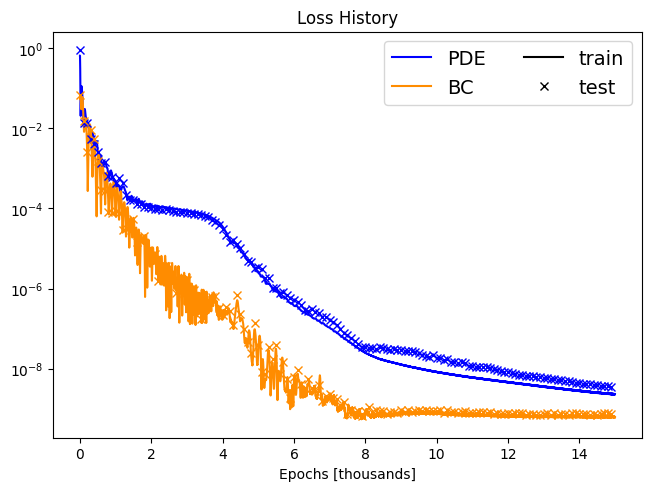

In [204]:
# Initialize neural network, optimization
# and prescribe a learning rate decay
model = FCNN(in_dim=2, width=32, out_dim=1).to(device)
optimizer = pytorch_optimizer.optimizer.soap.SOAP(
    model.parameters(),lr=1e-3, betas=(.997, .997),
    weight_decay=0.0,precondition_frequency=1
)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99995)

# Define number of training iterations
Nepochs        = 15000
pbar = tqdm.trange(Nepochs, ncols=128)

# Initialize lists to store training and test loss
pde_loss_hist     , bc_loss_hist       = [], []
pde_test_loss_hist, bc_test_loss_hist  = [], []

# Main training loop
for i in pbar:
    model.train()
    optimizer.zero_grad()

    lp   = torch.mean(pde(model, Xpde)**2)
    lb   = torch.mean(BC(model, Xbc)**2)

    loss = lp +lb
    loss.backward()
    optimizer.step()
    scheduler.step()

    pde_loss_hist.append(lp.detach().cpu().numpy())
    bc_loss_hist.append(lb.detach().cpu().numpy())

    model.eval()
    lp_t = torch.mean(pde(model, Xpde_test)**2)
    with torch.no_grad():
        lb_t = torch.mean(BC(model, Xbc_test)**2)

    pde_test_loss_hist.append(lp_t.detach().cpu().numpy())
    bc_test_loss_hist.append(lb_t.cpu().numpy())

    pbar.set_postfix({
        "L_PDE": f"{lp.item():.3e}"  ,"L_BC": f"{lb.item():.3e}",
        "T_PDE": f"{lp_t.item():.3e}","T_BC": f"{lb_t.item():.3e}",
    })

# plot loss history
fig, ax = plt.subplots(constrained_layout=True)
ax.set_xlabel("Epochs [thousands]")
ax.set_title("Loss History")
ax.set_yscale("log")

epochs = np.arange(len(pde_loss_hist))/1e3

ax.plot(epochs,pde_loss_hist,label="PDE",c='blue')
ax.plot(epochs,bc_loss_hist,label="BC",c='darkorange')
ax.plot(epochs, pde_test_loss_hist, marker='x',c='blue',ls='none', markevery=100)
ax.plot(epochs, bc_test_loss_hist, marker='x',c='darkorange',ls='none', markevery=100)
ax.plot([],[],ls='-',label='train',c='black')
ax.plot([],[],ls='none',marker='x',label='test',color='black')
ax.legend(fontsize=14,ncol=2)
plt.show()

#### Plot the learned solution, and the corresponding PDE residual error

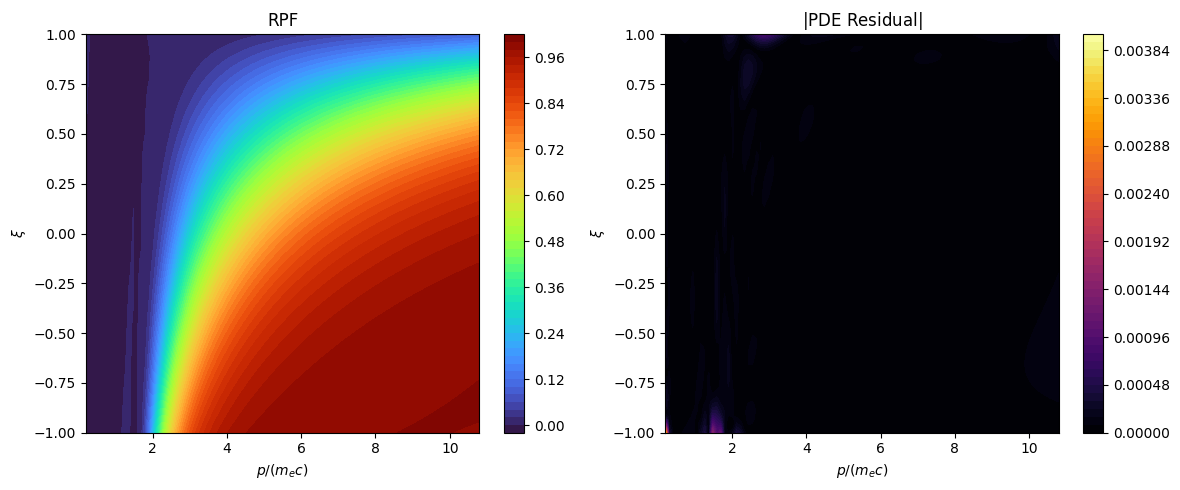

In [205]:
num_p, num_xi = 100, 99
pGrid      = np.linspace(pMin,  pMax,  num_p)
xiGrid     = np.linspace(xiMin, xiMax, num_xi)

pNorm  = (pGrid-pMin)/(pMax-pMin)
xiNorm = (xiGrid-xiMin)/(xiMax-xiMin)

pMesh_norm, xiMesh_norm = np.meshgrid(pNorm, xiNorm, indexing='ij')
pMesh  = pMesh_norm  * (pMax  - pMin)  + pMin
xiMesh = xiMesh_norm * (xiMax - xiMin) + xiMin

fig, ax = plt.subplots(ncols=2,constrained_layout=True,figsize=(12,5))
fig.set_tight_layout(True)

Xpred = torch.cat([
    torch.tensor(pMesh_norm).to(device).reshape(-1,1),
    torch.tensor(xiMesh_norm).to(device).reshape(-1,1),
],dim=1)
    
model.eval()
with torch.no_grad():
    P = model(Xpred).detach().reshape(pMesh.shape).cpu().numpy()
pde_res = pde(model, Xpred).detach().reshape(pMesh.shape).cpu().numpy()

cp0 = ax[0].contourf(pMesh,xiMesh,P,levels=50,cmap='turbo')
cp1 = ax[1].contourf(pMesh,xiMesh,abs(pde_res),levels=50,cmap='inferno')

fig.colorbar(cp0,ax=ax[0])
fig.colorbar(cp1,ax=ax[1])

ax[1].set_xlabel(r'$p/(m_ec)$')
ax[0].set_xlabel(r'$p/(m_ec)$')
ax[1].set_ylabel(r'$\xi$')
ax[0].set_ylabel(r'$\xi$')
ax[0].set_title('RPF')
ax[1].set_title('$|$PDE Residual$|$')

plt.show()

/blue/cmcdevitt/j.arnaud/git_home/deeprunaway/deeprunaway-env/lib/python3.10/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Epoch    1 | MSE 3.457624e-01
Epoch  200 | MSE 2.864740e-06
Epoch  400 | MSE 2.921100e-05
Epoch  600 | MSE 2.226665e-06
Epoch  800 | MSE 1.166743e-04
Epoch 1000 | MSE 1.879772e-06
Epoch 1200 | MSE 2.213080e-06
Epoch 1400 | MSE 4.359745e-06
Epoch 1600 | MSE 1.835163e-06
Epoch 1800 | MSE 1.244273e-06
Epoch 2000 | MSE 1.309550e-06


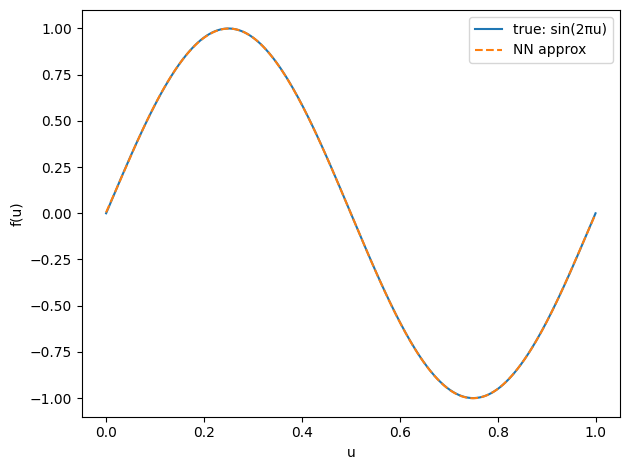

In [1]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(0)

# --- Data: u in [0, 1], target = sin(2*pi*u) ---
def make_data(n=1024, device="cpu"):
    u = torch.rand(n, 1, device=device)  # Uniform in [0,1]
    y = torch.sin(2 * math.pi * u)
    return u, y

# --- Model: simple MLP regressor ---
class SinApproximator(nn.Module):
    def __init__(self, hidden=64, depth=3):
        super().__init__()
        layers = []
        in_dim = 1
        for _ in range(depth):
            layers += [nn.Linear(in_dim, hidden), nn.Tanh()]
            in_dim = hidden
        layers += [nn.Linear(in_dim, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, u):
        return self.net(u)

def train(device="cpu"):
    # Hyperparameters
    n_train = 4096
    batch_size = 256
    epochs = 2000
    lr = 1e-3

    # Data
    u_train, y_train = make_data(n_train, device=device)

    # Model + optimizer + loss
    model = SinApproximator(hidden=64, depth=3).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    # Training loop (mini-batch)
    for epoch in range(1, epochs + 1):
        idx = torch.randperm(n_train, device=device)
        u_shuf, y_shuf = u_train[idx], y_train[idx]

        model.train()
        total_loss = 0.0
        for i in range(0, n_train, batch_size):
            u_b = u_shuf[i:i+batch_size]
            y_b = y_shuf[i:i+batch_size]

            pred = model(u_b)
            loss = loss_fn(pred, y_b)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total_loss += loss.item() * u_b.size(0)

        if epoch % 200 == 0 or epoch == 1:
            print(f"Epoch {epoch:4d} | MSE {total_loss / n_train:.6e}")

    return model

def plot_result(model, device="cpu"):
    model.eval()
    u = torch.linspace(0, 1, 500, device=device).unsqueeze(1)
    with torch.no_grad():
        y_pred = model(u)
    y_true = torch.sin(2 * math.pi * u)

    u_cpu = u.squeeze(1).cpu()
    plt.figure()
    plt.plot(u_cpu, y_true.squeeze(1).cpu(), label="true: sin(2πu)")
    plt.plot(u_cpu, y_pred.squeeze(1).cpu(), "--", label="NN approx")
    plt.xlabel("u")
    plt.ylabel("f(u)")
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = train(device=device)
    plot_result(model, device=device)

In [2]:
# --- Saving ---
def save_model(model, path="sin_mlp_state_dict.pt"):
    """
    Recommended: save only the state_dict (weights).
    """
    torch.save(model.state_dict(), path)
    print(f"Saved model weights to: {path}")

torch.save(model, "sin_mlp_entire_model.pt")